In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [155]:
cp = pd.read_csv('car_price_cleaned.csv')
cp.head()

,Unnamed: 0,symboling,curbweight,enginesize,horsepower,citympg,highwaympg,price,fueltype_gas,carbody_hardtop,...,drivewheel_fwd,drivewheel_rwd,enginelocation_rear,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,0,3,2548,130,111,21,27,13495.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,3,2548,130,111,21,27,16500.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2,1,2823,152,154,19,26,16500.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,2,2337,109,102,24,30,13950.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,4,2,2824,136,115,18,22,17450.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [156]:
cp.info()

<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           202 non-null    int64  
 1   symboling            202 non-null    int64  
 2   curbweight           202 non-null    int64  
 3   enginesize           202 non-null    int64  
 4   horsepower           202 non-null    int64  
 5   citympg              202 non-null    int64  
 6   highwaympg           202 non-null    int64  
 7   price                202 non-null    float64
 8   fueltype_gas         202 non-null    float64
 9   carbody_hardtop      202 non-null    float64
 10  carbody_hatchback    202 non-null    float64
 11  carbody_sedan        202 non-null    float64
 12  carbody_wagon        202 non-null    float64
 13  drivewheel_fwd       202 non-null    float64
 14  drivewheel_rwd       202 non-null    float64
 15  enginelocation_rear  202 non-null    float64
 16  f

In [157]:
#creating dependent and independent variable
x = cp.drop('price', axis =1)
y = cp['price']

x.head()

,Unnamed: 0,symboling,curbweight,enginesize,horsepower,citympg,highwaympg,fueltype_gas,carbody_hardtop,carbody_hatchback,...,drivewheel_fwd,drivewheel_rwd,enginelocation_rear,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,0,3,2548,130,111,21,27,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,3,2548,130,111,21,27,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2,1,2823,152,154,19,26,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,2,2337,109,102,24,30,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,4,2,2824,136,115,18,22,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [158]:
#get list of columns
for col in x.columns:
    print (col)

Unnamed: 0
symboling
curbweight
enginesize
horsepower
citympg
highwaympg
fueltype_gas
carbody_hardtop
carbody_hatchback
carbody_sedan
carbody_wagon
drivewheel_fwd
drivewheel_rwd
enginelocation_rear
fuelsystem_2bbl
fuelsystem_4bbl
fuelsystem_idi
fuelsystem_mfi
fuelsystem_mpfi
fuelsystem_spdi
fuelsystem_spfi


In [159]:
#train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [160]:
x_train.shape

(151, 22)

In [161]:
'''#check multicolleniarity
corr = x_train.corr()
plt.figure(figsize=(20,18))
sns.heatmap(corr, annot= True)'''

'#check multicolleniarity\ncorr = x_train.corr()\nplt.figure(figsize=(20,18))\nsns.heatmap(corr, annot= True)'

In [162]:
#eliminate multicollinearity
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range (len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [163]:
corr_feature = correlation(x_train, .85)

In [164]:
print(corr_feature)

{'drivewheel_rwd', 'highwaympg', 'fuelsystem_idi'}


In [165]:
x_train.drop(corr_feature, axis = 1, inplace = True)
x_test.drop(corr_feature, axis = 1, inplace = True)

In [166]:
x_train.shape

(151, 19)

In [167]:
#scalling
from sklearn.preprocessing import StandardScaler
scaller = StandardScaler()
x_train_scaled = scaller.fit_transform(x_train)
x_test_scaled = scaller.transform(x_test)

In [168]:
x_train_scaled

array([[ 1.27912335,  1.81262403,  0.81020915, ...,  1.02006889,
        -0.20341905, -0.08164966],
       [-1.59970316,  0.98069021, -0.09533828, ...,  1.02006889,
        -0.20341905, -0.08164966],
       [ 0.4803738 , -0.68317745,  0.04367966, ...,  1.02006889,
        -0.20341905, -0.08164966],
       ...,
       [-0.1519696 ,  0.14875638, -1.19396619, ..., -0.98032595,
        -0.20341905, -0.08164966],
       [ 1.34568581,  0.98069021, -0.57031625, ..., -0.98032595,
        -0.20341905, -0.08164966],
       [ 0.01443656, -0.68317745,  1.42806668, ...,  1.02006889,
        -0.20341905, -0.08164966]], shape=(151, 19))

<Axes: >

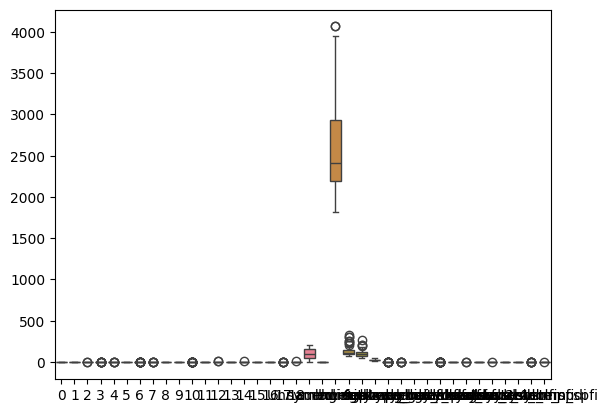

In [169]:
#outlier comparison between scallend and non scalled values
sns.boxplot(data=x_train_scaled)
sns.boxplot(data=x_train)

Linear Model

In [170]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x_train_scaled, y_train)
y_pred = lin_reg.predict(x_test_scaled)
print(y_pred)

[ 6221.24236718 26462.39856917  5440.44317313  6368.5139278
  9607.99083598 16624.94847963 26281.08731918 10275.88378849
  6520.31723633  6890.17207655 14851.42711093  5019.80584678
 13638.87551109  6073.35320786 16202.41378191 16618.16707052
 13630.9166449   6166.22830999 15200.13195888 23251.26306954
 31666.51951992 27433.59777829  7376.39814888  4924.68877694
 16527.3854687  11790.55634673 15776.16498552 23769.71851169
 25473.3304343  10223.24977817 19165.68793124  2063.66050931
 13649.83728477 17911.89156684 16991.86743881 21052.71915549
  6634.9914288   7767.31878578 16946.54360297  5764.43882496
  6400.96647412 18505.66694386  9767.86980367  6680.77553448
 16498.23049297 15936.60164342 17023.38894902  6444.5473785
  8819.11769543 11315.61651228 18349.09143701]


Text(0, 0.5, 'predicted values')

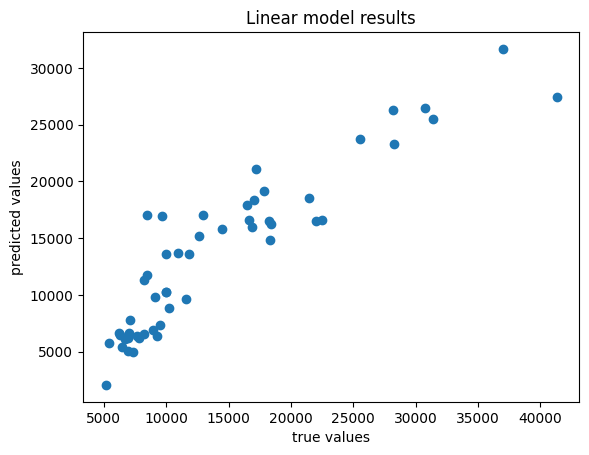

In [171]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Linear model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [172]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
Lin_mae = mean_absolute_error(y_test, y_pred)
Lin_score = r2_score(y_test, y_pred)
Lin_adj_score = 1-(1-Lin_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)

print('mean absolute error is: ', Lin_mae)
print('r2 score  is: ', Lin_score)
print('adjsuted r2 score  is: ', Lin_adj_score)

mean absolute error is:  2649.0698041273035
r2 score  is:  0.8202378589145553
adjsuted r2 score  is:  0.7100610627654117


Ridge regression

In [173]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge()
ridge_reg.fit(x_train_scaled, y_train)
y_pred = ridge_reg.predict(x_test_scaled)
print(y_pred)

[ 6195.06480242 26532.79295529  5196.31358747  6407.7934192
  9524.83576646 16557.11611494 26323.69829577 10223.85806226
  6552.45955836  6787.55385346 14901.22102088  4983.21116065
 13692.13671313  6044.33348671 16317.24963347 16676.48780197
 13595.29398132  6187.64274519 15163.30722638 23241.89972996
 31423.58678286 27450.46838632  7399.21779989  4972.03710294
 16633.59061712 11771.01708867 15706.57191066 23796.63043133
 25643.73767029 10226.19825983 19206.25756798  1860.09705934
 13613.91288201 17992.02894934 17084.0236084  21072.56422062
  6690.22594859  7746.68308534 17040.43685887  5653.99761482
  6431.90436755 18587.18280076  9784.97987208  6650.58798774
 16590.797735   15901.76857674 17101.43074619  6319.01082593
  8848.36954485 11327.79930829 18334.06625507]


Text(0, 0.5, 'predicted values')

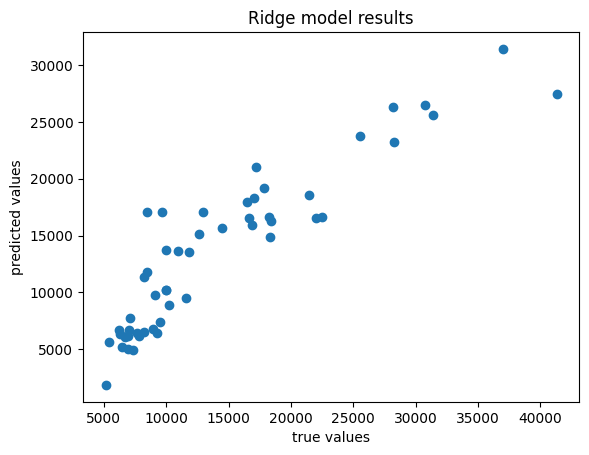

In [174]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Ridge model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [175]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
ridge_mae = mean_absolute_error(y_test, y_pred)
ridge_score = r2_score(y_test, y_pred)
ridge_adj_score = 1-(1-ridge_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)

print('mean absolute error is: ', ridge_mae)
print('r2 score  is: ', ridge_score)
print('adjsuted r2 score  is: ', ridge_adj_score)

mean absolute error is:  2647.3079856702066
r2 score  is:  0.8197803089792689
adjsuted r2 score  is:  0.7093230789988207


Lasso Regression

In [176]:
from sklearn.linear_model import Lasso
Lasso_reg = Lasso()
Lasso_reg.fit(x_train_scaled, y_train)
y_pred = Lasso_reg.predict(x_test_scaled)
print(y_pred)

[ 6217.11161161 26461.29148915  5425.62468358  6374.63090309
  9573.2104361  16630.0249984  26271.28714339 10270.70674069
  6525.87874065  6869.01952219 14852.96025441  5017.06872861
 13647.38477229  6070.19554901 16199.21958907 16620.37641476
 13618.71440685  6168.51795669 15205.8347828  23247.49882092
 31618.40845091 27429.41048731  7372.84548335  4925.12602034
 16536.0680325  11790.70714876 15780.04141703 23769.97196599
 25444.9280456  10222.82484258 19154.6103301   2029.07512261
 13637.57465658 17900.96749025 16991.44473095 21056.203348
  6646.67802637  7761.61131945 16946.26503461  5748.86012452
  6404.22173546 18518.47907732  9785.2770888   6672.53556087
 16507.56055961 15937.60048006 17048.98167579  6421.00582985
  8819.71885365 11321.01192225 18349.79173944]


Text(0, 0.5, 'predicted values')

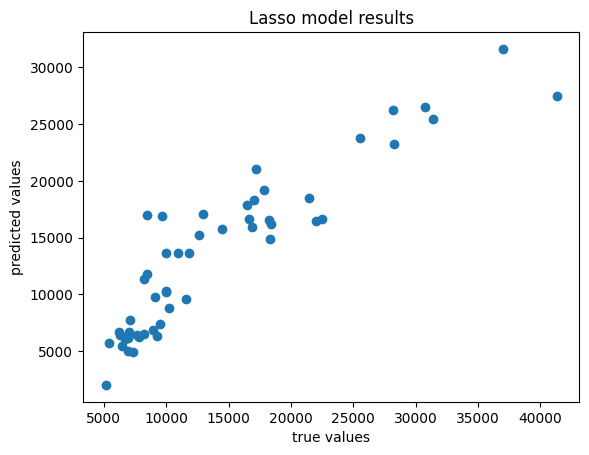

In [177]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Lasso model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [178]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
Lasso_mae = mean_absolute_error(y_test, y_pred)
Lasso_score = r2_score(y_test, y_pred)
lasso_adj_score = 1-(1-Lasso_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)


print('mean absolute error is: ', Lasso_mae)
print('r2 score  is: ', Lasso_score)
print('adjsuted r2 score  is: ', lasso_adj_score)

mean absolute error is:  2651.2593877755744
r2 score  is:  0.8198521861558131
adjsuted r2 score  is:  0.7094390099287309


Decision Tree

In [179]:
from sklearn.tree import DecisionTreeRegressor
Tree_reg = DecisionTreeRegressor()
Tree_reg.fit(x_train, y_train)
y_pred = Tree_reg.predict(x_test)
print(y_pred)

[ 5118. 36880.  5399.  8358.  9980. 11900. 31600. 11248.  8058.  6575.
  8921.  7898. 11549.  6189. 18950. 16515. 13645.  7738. 14869. 31600.
 34028. 36880.  8845.  7295. 20970.  8845. 14869. 31600. 35056.  6989.
 18950.  5399. 13645. 18150. 11199. 19699.  7603.  7775. 11199.  5572.
  7957. 22625.  7895.  6377. 16500. 13415. 14869.  5572.  8013.  9279.
 16900.]


Text(0, 0.5, 'predicted values')

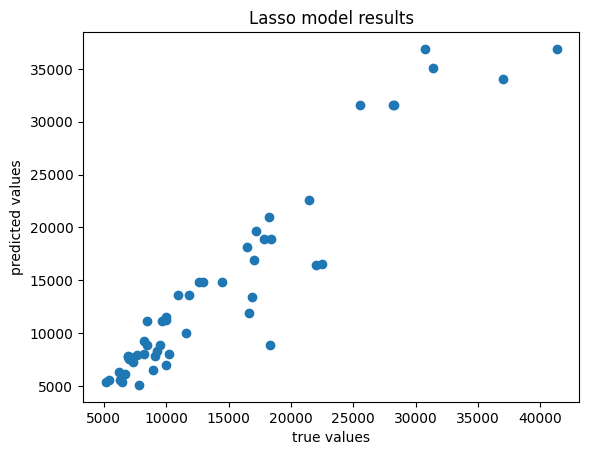

In [180]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Lasso model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [181]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
tree_mae = mean_absolute_error(y_test, y_pred)
tree_score = r2_score(y_test, y_pred)
tree_adj_score = 1-(1-tree_score)*(len(y_test)-1)/((len(y_test)) - x_test.shape[1]-1)


print('mean absolute error is: ', tree_mae)
print('r2 score  is: ', tree_score)
print('adjsuted r2 score  is: ', tree_adj_score)

mean absolute error is:  2104.8006470588234
r2 score  is:  0.8879119436123075
adjsuted r2 score  is:  0.8192128122779153


Random forest regressor

In [182]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(x_train, y_train)
y_pred = forest_reg.predict(x_test)
print(y_pred)

[ 6256.27  34151.24   5697.81   8084.63   9376.98  15101.95  25638.44
 10878.28   7881.66   6911.455 11445.35   7785.93  11940.28   6264.95
 17829.75  18396.48  12294.34   7666.37  14398.97  25414.34  32210.46
 34435.24   8539.8    7385.67  14282.41   9974.68  14610.41  25208.49
 33112.98   9580.65  20563.15   5662.235 12294.34  17866.36  11600.99
 18112.24   7498.39   7758.52  11595.57   5766.54   8185.89  19044.67
  8371.39   6307.8   14959.19  16206.57  18909.61   6134.665 10642.35
  9564.11  17906.03 ]


Text(0, 0.5, 'predicted values')

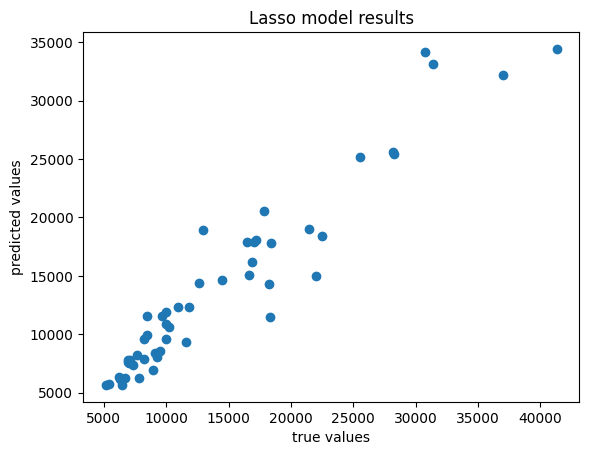

In [183]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Lasso model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [184]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
forest_mae = mean_absolute_error(y_test, y_pred)
forest_score = r2_score(y_test, y_pred)
forest_adj_score = 1-(1-forest_score)*(len(y_test)-1)/((len(y_test)) - x_test.shape[1]-1)


print('mean absolute error is: ', forest_mae)
print('r2 score  is: ', forest_score)
print('adjsuted r2 score  is: ', forest_adj_score)

mean absolute error is:  1790.4413333333337
r2 score  is:  0.9113574445672239
adjsuted r2 score  is:  0.8570281363987482


ElasticNet Regression

In [185]:
from sklearn.linear_model import ElasticNet
elastic_reg = ElasticNet()
elastic_reg.fit(x_train_scaled, y_train)
y_pred = elastic_reg.predict(x_test_scaled)
print(y_pred)

[ 6194.43511445 25425.28198535  3654.25239628  7290.27257784
  9979.29362208 16469.60029607 24895.22174884 10325.96763724
  7457.12620898  6315.28242171 14481.31989672  5423.39264646
 14218.99632488  6028.7222145  18233.29453171 16720.97684439
 12796.4083227   6918.53653693 14618.13445226 21375.65438426
 27571.77870384 25884.14384897  7912.4970025   5773.03673965
 17472.2859234  11201.88520064 14885.88071796 22141.24674941
 26355.75887257 11049.25810989 19543.28879418   977.53128918
 12808.54461961 18771.76440316 18139.53885906 20295.40142148
  7206.8649372   7892.00135692 18114.8426112   5005.07222515
  7830.2053535  19031.04358929 10015.08750096  6506.14124084
 17178.22169081 16087.2609787  16736.27449622  5431.16411328
 10000.10559853 11096.5508427  17224.48253497]


Text(0, 0.5, 'predicted values')

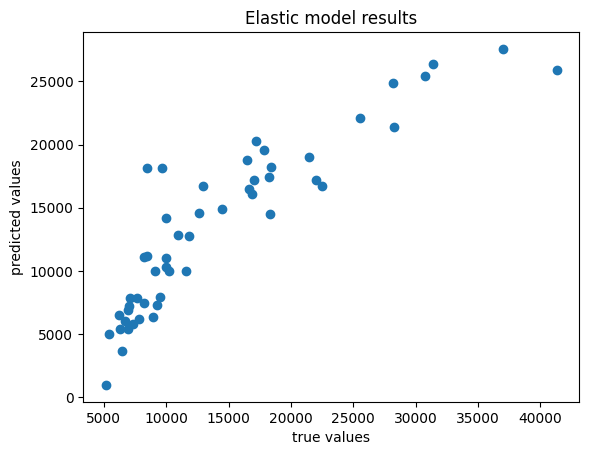

In [186]:
#plot results
plt.scatter(y_test, y_pred)
plt.title('Elastic model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

In [187]:
#calculate mae and R2
from sklearn.metrics import mean_absolute_error, r2_score
elastic_mae = mean_absolute_error(y_test, y_pred)
elastic_score = r2_score(y_test, y_pred)
elastic_adj_score = 1-(1-elastic_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)


print('mean absolute error is: ', elastic_mae)
print('r2 score  is: ', elastic_score)
print('adjsuted r2 score  is: ', elastic_adj_score)

mean absolute error is:  2702.8145487400006
r2 score  is:  0.7791290564036288
adjsuted r2 score  is:  0.6437565425864982


Hyperparameter tuning and cross validation

mean absolute error is:  2663.4334126716403
r2 score  is:  0.814214260934212
adjsuted r2 score  is:  0.7003455821519549
10.0


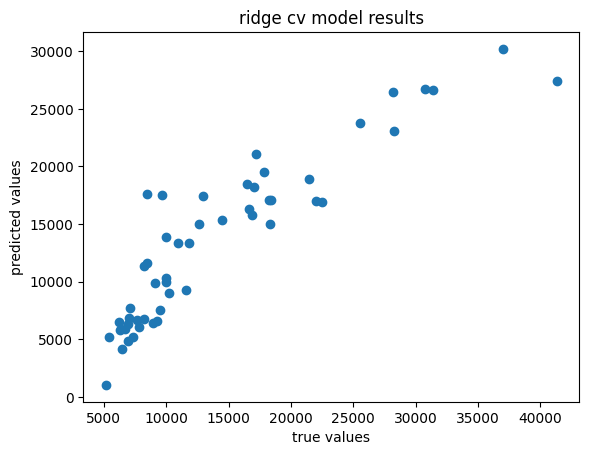

In [188]:
'''cross validation with ridge regresion'''
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV()
ridgecv.fit(x_train_scaled, y_train)
y_pred = ridgecv.predict(x_test_scaled)

plt.scatter(y_test, y_pred)
plt.title('ridge cv model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

ridgecv_mae = mean_absolute_error(y_test, y_pred)
ridgecv_score = r2_score(y_test, y_pred)
ridgecv_adj_score = 1-(1-ridgecv_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)


print('mean absolute error is: ', ridgecv_mae)
print('r2 score  is: ', ridgecv_score)
print('adjsuted r2 score  is: ', ridgecv_adj_score)

print(ridgecv.alpha_)



mean absolute error is:  2666.87364603905
r2 score  is:  0.8144673621229945
adjsuted r2 score  is:  0.7007538098757976
10.0


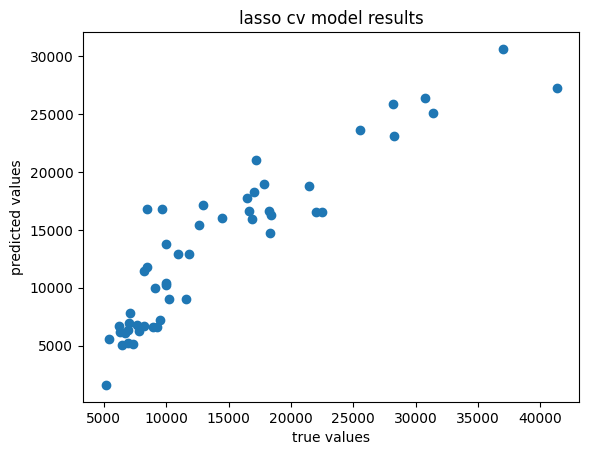

In [189]:
'''cross validation with lasso regresion'''
from sklearn.linear_model import LassoCV
lassocv = LassoCV()
lassocv.fit(x_train_scaled, y_train)
y_pred = lassocv.predict(x_test_scaled)

plt.scatter(y_test, y_pred)
plt.title('lasso cv model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

lassocv_mae = mean_absolute_error(y_test, y_pred)
lassocv_score = r2_score(y_test, y_pred)
lassocv_adj_score = 1-(1-lassocv_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)


print('mean absolute error is: ', lassocv_mae)
print('r2 score  is: ', lassocv_score)
print('adjsuted r2 score  is: ', lassocv_adj_score)

print(ridgecv.alpha_)

mean absolute error is:  2666.87364603905
r2 score  is:  0.8144673621229945
adjsuted r2 score  is:  0.7007538098757976


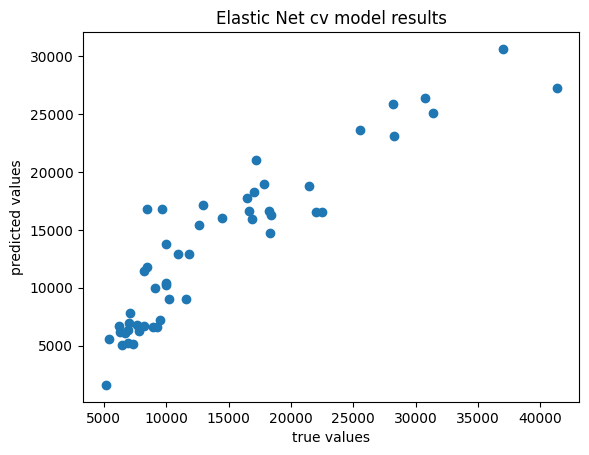

In [190]:
'''cross validation with elasticnet regresion'''
from sklearn.linear_model import ElasticNetCV
elasticcv = ElasticNetCV(l1_ratio= 1)
elasticcv.fit(x_train_scaled, y_train)
y_pred = elasticcv.predict(x_test_scaled)

plt.scatter(y_test, y_pred)
plt.title('Elastic Net cv model results')
plt.xlabel('true values')
plt.ylabel('predicted values')

elasticcv_mae = mean_absolute_error(y_test, y_pred)
elasticcv_score = r2_score(y_test, y_pred)
elasticcv_adj_score = 1-(1-elasticcv_score)*(len(y_test)-1)/((len(y_test)) - x_test_scaled.shape[1]-1)


print('mean absolute error is: ', elasticcv_mae)
print('r2 score  is: ', elasticcv_score)
print('adjsuted r2 score  is: ', elasticcv_adj_score)


Compare Final Results

In [191]:
final_results = {'Model' :[
                    'Linear Regression',
                    'Ridge Regression',
                    'Ridge CV Regression',
                    'Lasso Regression',
                    'Lasso CV Regression',
                    'ElasticNet Regression',
                    'ElasticNet CV Regression',
                    'Decision Tree Regression',
                    'Random Forest Regression'
                    ],
                "R2 Score": [
                    Lin_score,
                    ridge_score,
                    ridgecv_score,
                    Lasso_score,
                    lassocv_score,
                    elastic_score,
                    elasticcv_score,
                    tree_score,
                    forest_score
                ] ,
                'Adjusted R2 Score': [
                    Lin_adj_score,
                    ridge_adj_score,
                    ridgecv_adj_score,
                    lasso_adj_score,
                    lassocv_adj_score,
                    elastic_adj_score,
                    elasticcv_adj_score,
                    tree_adj_score,
                    forest_adj_score
                ],
                'Mean Absolute Error' : [
                    Lin_mae,
                    ridge_mae,
                    ridgecv_mae,
                    Lasso_mae,
                    lassocv_mae,
                    elastic_mae,
                    elasticcv_mae,
                    tree_mae,
                    forest_mae
                ]
                 }

comparison_df = pd.DataFrame(final_results)
print(comparison_df)

                      Model  R2 Score  Adjusted R2 Score  Mean Absolute Error
0         Linear Regression  0.820238           0.710061          2649.069804
1          Ridge Regression  0.819780           0.709323          2647.307986
2       Ridge CV Regression  0.814214           0.700346          2663.433413
3          Lasso Regression  0.819852           0.709439          2651.259388
4       Lasso CV Regression  0.814467           0.700754          2666.873646
5     ElasticNet Regression  0.779129           0.643757          2702.814549
6  ElasticNet CV Regression  0.814467           0.700754          2666.873646
7  Decision Tree Regression  0.887912           0.819213          2104.800647
8  Random Forest Regression  0.911357           0.857028          1790.441333


In [192]:
corr_with_target = cp.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(corr_with_target.head(15))

price                  1.000000
enginesize             0.873555
curbweight             0.834523
horsepower             0.806481
drivewheel_rwd         0.635936
fuelsystem_mpfi        0.512249
enginelocation_rear    0.325069
carbody_hardtop        0.224652
carbody_sedan          0.124845
fuelsystem_idi         0.102536
fuelsystem_mfi        -0.003545
fuelsystem_4bbl       -0.018752
fuelsystem_spfi       -0.020453
carbody_wagon         -0.039048
fuelsystem_spdi       -0.064172
Name: price, dtype: float64
